In [1]:
import random
import matplotlib.pyplot as plt
from pathlib import Path

from src.preprocessing import *
from src.utils import *
from src.preprocessing_teresa import *

# Group all paths by serie and pick one randomly to test
paths = get_all_image_paths()
series = group_paths_by_serie(paths)

print(f"Total series found: {len(series)}")

random_serie_key = random.choice(list(series.keys()))
random_serie_paths = series[random_serie_key]

print(f"Selected serie : {random_serie_key}")
print(f"Frames in serie: {len(random_serie_paths)}")

SEED = 33

Total images found: 8325
Total series found: 214
Selected serie : 085/5
Frames in serie: 51


Step 1 — Background subtraction

We first remove the slow-varying illumination background using Gaussian subtraction.

In [ ]:
KERNEL_SIZE = 21

browse_background_grid(series, n=9, seed=SEED)

interactive(children=(IntSlider(value=21, description='Kernel size', layout=Layout(width='500px'), max=201, mi…

Step 2 — Compute adaptive CLAHE clip limits per serie

Instead of using a fixed clip limit for every patient/session, we estimate an optimal CLAHE clip limit independently for each serie.

Workflow:

Take the middle frame of the serie
Apply background subtraction
Sweep multiple CLAHE clip values
Score each using the composite metric:
entropy (contrast)
tenengrad (sharpness)
Keep the best clip limit

In [3]:
KERNEL_SIZE = 21

clip_table = compute_optimal_clips_for_series(
    series_dict=series,
    load_fn=load_image,
    bg_subtract_fn=subtract_background,
    kernel_size=KERNEL_SIZE,
    clip_range=(0.5, 4.0),
    n_steps=20,
    metric="composite",
    alpha=0.6,
    beta=0.4,
    verbose=True,
)

  [1/214] 002/5 → clip=4.00
  [21/214] 019/5 → clip=4.00
  [41/214] 022/7 → clip=4.00
  [61/214] 029/7 → clip=4.00
  [81/214] 040/2 → clip=4.00
  [101/214] 048/5 → clip=4.00
  [121/214] 055/6 → clip=4.00
  [141/214] 067/7 → clip=4.00
  [161/214] 077/6 → clip=4.00
  [181/214] 085/4 → clip=4.00
  [201/214] 095/7 → clip=4.00
  [214/214] 099/8 → clip=4.00


Step 3 — Distribution of optimal clip limits

Useful to verify whether the adaptive values are stable across the dataset.

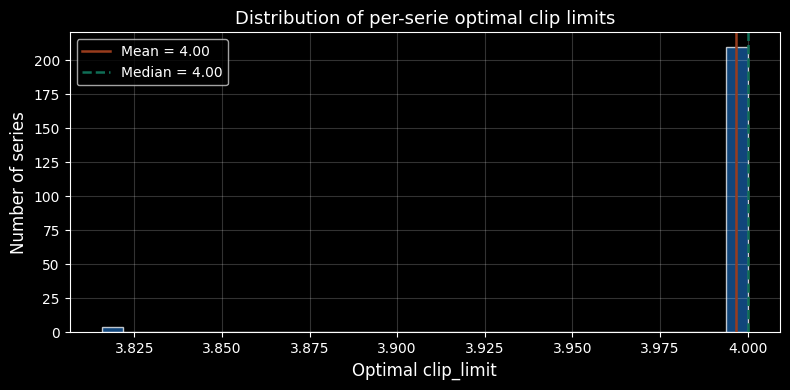

Series evaluated : 214
Mean clip         : 3.997
Median clip       : 4.000
Std               : 0.025
Min / Max         : 3.82 / 4.00


In [4]:
plot_clip_distribution(clip_table)

Step 4 — Compare fixed vs adaptive CLAHE

Left = background subtraction only
Middle = fixed CLAHE
Right = adaptive CLAHE using the optimal clip for that serie.

In [ ]:
browse_adaptive_vs_fixed_grid(
    series_dict=series,
    clip_table=clip_table,
    load_fn=load_image,
    bg_subtract_fn=subtract_background,
    kernel_size=KERNEL_SIZE,
    n=9,
    seed=SEED,
)

interactive(children=(FloatSlider(value=2.0, description='Fixed clip', layout=Layout(width='450px'), max=8.0, …

Step 5 — Visualise metric curves for one serie

This helps understand how entropy and sharpness evolve as clip_limit changes.

Metric curve for: 088/1


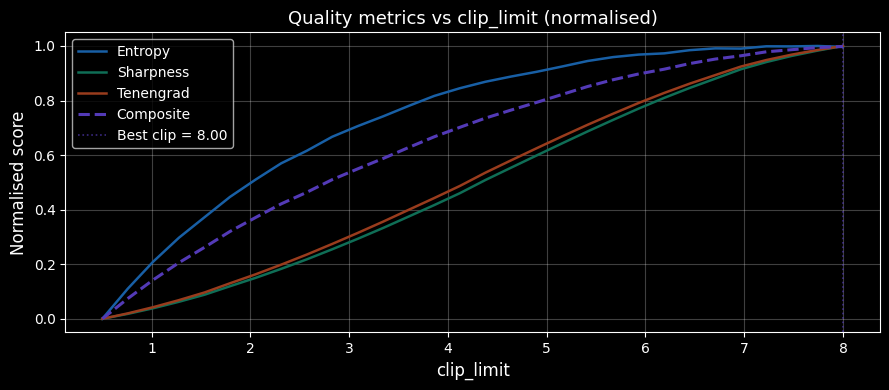

In [6]:
serie_key = random.choice(list(series.keys()))
serie_paths = series[serie_key]

mid_path = get_middle_frame(serie_paths)
img = load_image(mid_path)

bg = subtract_background(img, kernel_size=KERNEL_SIZE)

print(f"Metric curve for: {serie_key}")

plot_metric_curve(bg)

Step 6 — Apply adaptive CLAHE to a full serie

This applies the per-serie optimal clip limit to every frame.

In [7]:
serie_key = random.choice(list(series.keys()))
serie_paths = series[serie_key]

print(f"Applying adaptive CLAHE to serie: {serie_key}")

optimal_clip = clip_table.get(serie_key, 2.0)
print(f"Optimal clip limit: {optimal_clip:.2f}")

frames = []
for path in serie_paths:
    img = load_image(path)

    bg = subtract_background(img, kernel_size=KERNEL_SIZE)

    enhanced = apply_adaptive_clahe(
        bg,
        serie_key=serie_key,
        clip_table=clip_table,
    )

    frames.append(enhanced)

print(f"Processed {len(frames)} frames")

Applying adaptive CLAHE to serie: 018/6
Optimal clip limit: 4.00
Processed 42 frames


Step 7 — Browse adaptive CLAHE over time

In [8]:
from ipywidgets import interact, IntSlider

serie_key = random.choice(list(series.keys()))
serie_paths = series[serie_key]

optimal_clip = clip_table.get(serie_key, 2.0)

print(f"Serie: {serie_key}")
print(f"Adaptive clip: {optimal_clip:.2f}")


def browse(frame_idx):
    img = load_image(serie_paths[frame_idx])

    bg = subtract_background(img, kernel_size=KERNEL_SIZE)

    adaptive = apply_adaptive_clahe(
        bg,
        serie_key=serie_key,
        clip_table=clip_table,
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original")

    axes[1].imshow(adaptive, cmap="gray")
    axes[1].set_title(f"Adaptive CLAHE (clip={optimal_clip:.2f})")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


interact(
    browse,
    frame_idx=IntSlider(
        min=0,
        max=len(serie_paths)-1,
        step=1,
        value=len(serie_paths)//2,
        description="Frame"
    ),
    continuous_update=False
)

Serie: 075/1
Adaptive clip: 4.00


interactive(children=(IntSlider(value=8, description='Frame', max=15), Output()), _dom_classes=('widget-intera…

<function __main__.browse(frame_idx)>

 Adaptive CLAHE per Serie — No Background Subtraction

Total images found: 8325
Total series found: 214
  [1/214] 002/5 → clip=4.00
  [21/214] 019/5 → clip=4.00
  [41/214] 022/7 → clip=4.00
  [61/214] 029/7 → clip=4.00
  [81/214] 040/2 → clip=4.00
  [101/214] 048/5 → clip=4.00
  [121/214] 055/6 → clip=4.00
  [141/214] 067/7 → clip=4.00
  [161/214] 077/6 → clip=4.00
  [181/214] 085/4 → clip=4.00
  [201/214] 095/7 → clip=4.00
  [214/214] 099/8 → clip=4.00


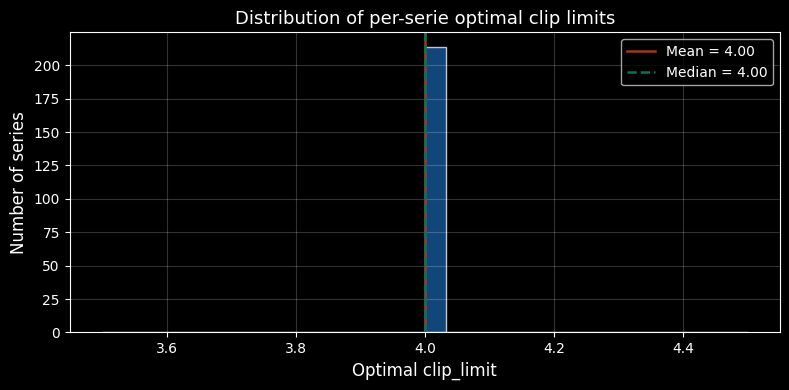

Series evaluated : 214
Mean clip         : 4.000
Median clip       : 4.000
Std               : 0.000
Min / Max         : 4.00 / 4.00


interactive(children=(FloatSlider(value=2.0, description='Fixed clip', layout=Layout(width='450px'), max=8.0, …

Metric curve for: 066/9


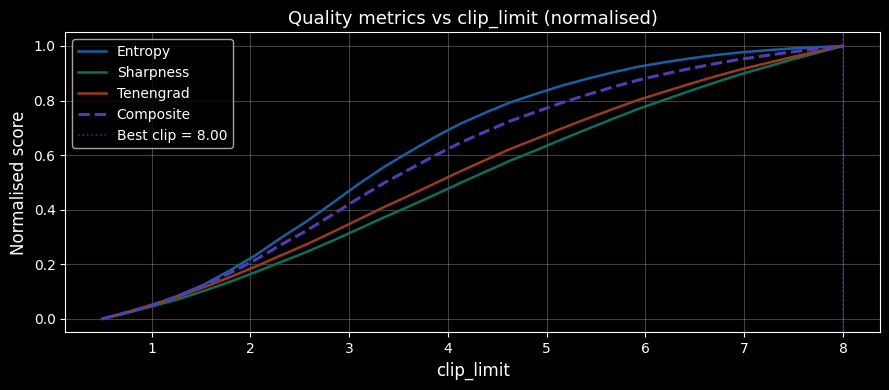

Serie: 055/6
Adaptive clip: 4.00
Processed 9 frames


interactive(children=(IntSlider(value=4, description='Frame', max=8), Output()), _dom_classes=('widget-interac…

<function __main__.browse(frame_idx)>

In [11]:
import random
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

from src.preprocessing import *
from src.utils import *
from src.preprocessing_teresa import *

# ─────────────────────────────────────────────────────────────
# Load dataset
# ─────────────────────────────────────────────────────────────

paths = get_all_image_paths()
series = group_paths_by_serie(paths)

print(f"Total series found: {len(series)}")

SEED = 33

# ─────────────────────────────────────────────────────────────
# Compute adaptive CLAHE clip limits
# WITHOUT background subtraction
# ─────────────────────────────────────────────────────────────

clip_table = compute_optimal_clips_for_series(
    series_dict=series,
    load_fn=load_image,

    # identity function → no BG subtraction
    bg_subtract_fn=lambda img, kernel_size: img,

    kernel_size=1,
    clip_range=(0.5, 4.0),
    n_steps=20,
    metric="composite",
    alpha=0.6,
    beta=0.4,
    verbose=True,
)

# ─────────────────────────────────────────────────────────────
# Distribution of optimal clips
# ─────────────────────────────────────────────────────────────

plot_clip_distribution(clip_table)

# ─────────────────────────────────────────────────────────────
# Compare fixed vs adaptive CLAHE
# ─────────────────────────────────────────────────────────────

browse_adaptive_vs_fixed_grid(
    series_dict=series,
    clip_table=clip_table,
    load_fn=load_image,

    # no BG subtraction
    bg_subtract_fn=lambda img, kernel_size: img,

    kernel_size=1,
    n=9,
    seed=SEED,
)

# ─────────────────────────────────────────────────────────────
# Visualise metric curve for one serie
# ─────────────────────────────────────────────────────────────

serie_key = random.choice(list(series.keys()))
serie_paths = series[serie_key]

mid_path = get_middle_frame(serie_paths)
img = load_image(mid_path)

print(f"Metric curve for: {serie_key}")

plot_metric_curve(img)

# ─────────────────────────────────────────────────────────────
# Apply adaptive CLAHE to one serie
# ─────────────────────────────────────────────────────────────

serie_key = random.choice(list(series.keys()))
serie_paths = series[serie_key]

optimal_clip = clip_table.get(serie_key, 2.0)

print(f"Serie: {serie_key}")
print(f"Adaptive clip: {optimal_clip:.2f}")

frames = []

for path in serie_paths:
    img = load_image(path)

    enhanced = apply_adaptive_clahe(
        img,
        serie_key=serie_key,
        clip_table=clip_table,
    )

    frames.append(enhanced)

print(f"Processed {len(frames)} frames")


# ─────────────────────────────────────────────────────────────
# Interactive browser
# ─────────────────────────────────────────────────────────────

def browse(frame_idx):
    img = load_image(serie_paths[frame_idx])

    adaptive = apply_adaptive_clahe(
        img,
        serie_key=serie_key,
        clip_table=clip_table,
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original")

    axes[1].imshow(adaptive, cmap="gray")
    axes[1].set_title(f"Adaptive CLAHE (clip={optimal_clip:.2f})")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


interact(
    browse,
    frame_idx=IntSlider(
        min=0,
        max=len(serie_paths) - 1,
        step=1,
        value=len(serie_paths) // 2,
        description="Frame"
    ),
    continuous_update=False
)

